# FashionMNIST 흑백 이미지 분류

- **흑백(1채널) 28×28 픽셀** 의류 데이터셋
- 클래스 종류
```python
fashion_mnist_classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]
```

## 처리 순서

1. 데이터를 내려받아 Tensor로 전처리한다.
2. CNN 모델을 만들고 logits 10개를 출력한다.
3. 손실함수와 optimizer를 이용해 모델을 학습한다.
4. test 데이터로 성능을 평가한다.
5. 합성곱 계층이 만든 feature map을 관찰한다.

데이터셋 출처: [Fashion-MNIST GitHub](https://github.com/zalandoresearch/fashion-mnist)

## 1. 데이터 준비

### FashionMNIST train·test 데이터 다운로드

`download=True`는 `./data`에 파일이 없을 때 데이터를 자동으로 내려받는다. 이미 받은 데이터가 있으면 저장된 파일을 다시 사용한다.

In [6]:
from torchvision import datasets

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
)

print("train 데이터 수:", len(train_dataset))
print("test 데이터 수:", len(test_dataset))


train 데이터 수: 60000
test 데이터 수: 10000


### Dataset 객체 확인

`Dataset`은 이미지와 정답을 한 쌍씩 꺼낼 수 있게 관리한다. 내부 `data`와 `targets`를 보면 전체 이미지와 정답의 shape를 확인할 수 있다.

In [7]:
print(train_dataset)
print(test_dataset)

print("train 이미지 shape:", train_dataset.data.shape)
print("train 정답 shape:", train_dataset.targets.shape)
print("클래스 이름:", train_dataset.classes)


Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
train 이미지 shape: torch.Size([60000, 28, 28])
train 정답 shape: torch.Size([60000])
클래스 이름: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### 이미지 한 장과 label 확인

Dataset에서 `train_dataset[index]`를 사용하면 `(이미지, label)` 한 쌍을 얻는다. 원본 픽셀은 0~255 범위의 정수로 저장되어 있다.

In [8]:
sample_image, sample_label = train_dataset[0]

raw_image = train_dataset.data[0]

print("이미지 객체:", sample_image)
print("label:", sample_label)
print("클래스 이름:", train_dataset.classes[sample_label])
print("원본 shape:", raw_image.shape)
print("원본 dtype:", raw_image.dtype)
print("픽셀 범위:", raw_image.min().item(), "~", raw_image.max().item())
print(raw_image)


이미지 객체: <PIL.Image.Image image mode=L size=28x28 at 0x280B2EA4AD0>
label: 9
클래스 이름: Ankle boot
원본 shape: torch.Size([28, 28])
원본 dtype: torch.uint8
픽셀 범위: 0 ~ 255
tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
           0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,   1,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,   0,
          36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,   0,   3],
        [  0,   0,   0,   0,   0,   0,   0

### Channel 축 추가와 픽셀 정규화

PyTorch CNN은 이미지를 `(N, C, H, W)` 순서로 받는다.
흑백 이미지에는 `C=1`을 추가하고
학습 과정(신경망의 가중치 계산, 활성화 함수 결과)을 안정적으로 진행하기 위해 픽셀값을 0 ~ 255에서 -1 ~ 1 범위로 바꾼다.

In [9]:
print("전처리 전 shape:", train_dataset.data.shape)

# unsqueeze를 이용해서 흑백 채널을 나타내는 축 C=1 추가
train_images = train_dataset.data.unsqueeze(1).float() / 255.0
test_images = test_dataset.data.unsqueeze(1).float() / 255.0

train_images = (train_images - 0.5) / 0.5
test_images = (test_images - 0.5) / 0.5

# CrossEntropyLoss (다중 분류 손실 함수)는 입력 값이 long(int64) 타입이여야함
# -> 타입 맞춰주기
train_labels = train_dataset.targets.long()
test_labels = test_dataset.targets.long()

print("전처리 후 shape:", train_images.shape)
print("이미지 dtype:", train_images.dtype)
print(f"픽셀 범위: {train_images.min().item():.1f} ~ {train_images.max().item():.1f}")
print("정답 dtype:", train_labels.dtype)


전처리 전 shape: torch.Size([60000, 28, 28])
전처리 후 shape: torch.Size([60000, 1, 28, 28])
이미지 dtype: torch.float32
픽셀 범위: -1.0 ~ 1.0
정답 dtype: torch.int64


### Train·Validation 데이터 분할

train은 가중치를 학습하는 데이터이고 validation은 학습 중 성능을 점검하는 데이터이다. 공식 train 데이터의 15%를 validation으로 분리한다.

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split

train_indices, validation_indices = train_test_split(
    np.arange(len(train_images)),
    test_size=0.15,
    random_state=42,
)
# train 51_000, test 9_000, test 10_000 개 준비하는 과정
tr_images = train_images[train_indices]
tr_labels = train_labels[train_indices]
val_images = train_images[validation_indices]
val_labels = train_labels[validation_indices]

print("train:", tr_images.shape, tr_labels.shape)
print("validation:", val_images.shape, val_labels.shape)
print("test:", test_images.shape, test_labels.shape)


train: torch.Size([51000, 1, 28, 28]) torch.Size([51000])
validation: torch.Size([9000, 1, 28, 28]) torch.Size([9000])
test: torch.Size([10000, 1, 28, 28]) torch.Size([10000])


## 2. 데이터 시각화

### 무작위 의류 이미지 확인

학습 전에 이미지와 label이 올바르게 연결됐는지 확인한다. 화면에 표시할 때는 -1~1로 정규화한 값을 다시 0~1로 되돌린다.

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
tensor([9, 8, 2, 4, 5, 1, 6, 5, 8, 0])
Ankle boot


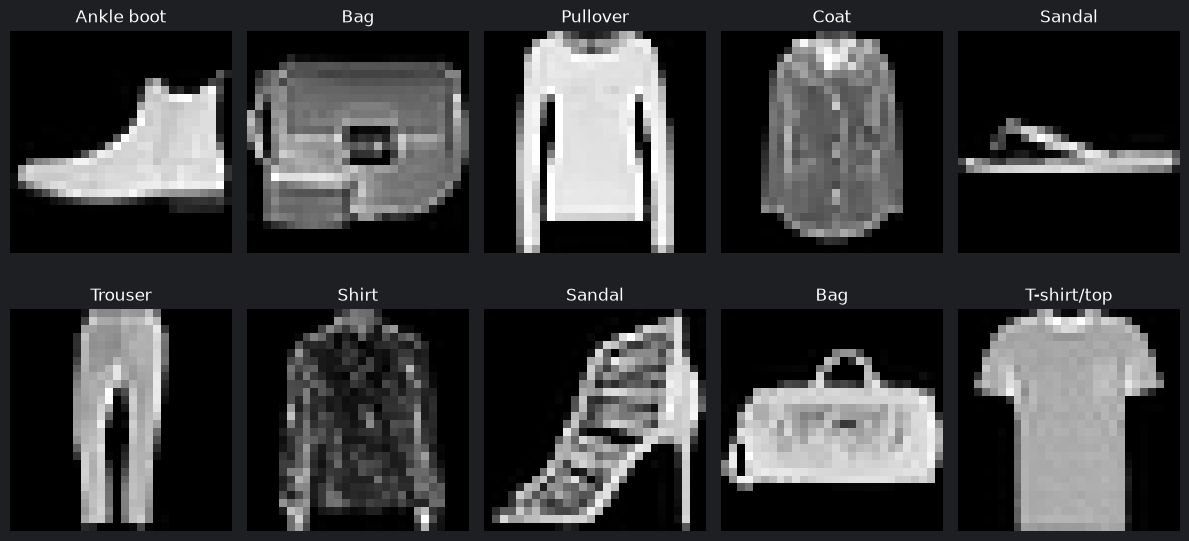

In [11]:
import matplotlib.pyplot as plt

class_names = train_dataset.classes
print(class_names)

random_generator = np.random.default_rng(42)
random_indices = random_generator.choice(len(tr_images), 10, replace=False)
random_images = tr_images[random_indices]
random_labels = tr_labels[random_indices]
print(random_labels)
print(class_names[random_labels[0]])

plt.figure(figsize=(12, 6))

for index in range(10):
    plt.subplot(2, 5, index + 1)

    display_image = random_images[index].squeeze(0) * 0.5 + 0.5
    label_index = random_labels[index].item()

    plt.imshow(display_image, cmap="gray")
    plt.title(class_names[label_index])
    plt.axis("off")

plt.tight_layout()
plt.show()


## 3. CNN 모델 생성

### FashionMNISTCNN 클래스 정의

합성곱 계층은 이미지 특징을 찾고, 완전연결 계층은 찾은 특징으로 10개 클래스를 분류한다. 마지막 출력은 확률이 아닌 **logits 10개**이다.

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# torch를 이용해서 딥러닝 모델, DataLoader 이용 시
# 초기 가중치, 데이터 load 순서를 고정
torch.manual_seed(42)

# CNN 모델 생성
class FashionMNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # 첫 번째 합성곱 층 생성
        # - N개의 이미지 흑백(1채널), 높이/너비 28px을 받아서
        # 32개의 feature map을 만들어 출력
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1,
            stride=1,
        )

        # 두 번째 합성곱
        # - 32채널을 받아 64개의 feature map을 출력
        # - padding=0, stride=1, kernel_size=3
        # - 패딩이 없어서 크기가 28x28 -> 26x26 감소
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=0,
            stride=1,
        )

        # 2x2 MaxPool 생성
        # -> 2x2 영역 내 최댓값을 추출하여 새 feature map 생성
        # -> 보통 크기가 1/2로 감소
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # FC층에서 사용할 Flatten 생성
        self.flatten = nn.Flatten()

        # Dropout을 이용해서 학습 효율 높이고, 과적합 방지
        self.dropout1 = nn.Dropout(p=0.3)

        # in_features 값: 채널 수 * 높이 * 너비
        # out_features 값: 정답(class)의 개수 == 마지막으로 출력할 logit 수
        self.fc1 = nn.Linear(in_features=64 * 13 * 13, out_features=100)

        # Dropout을 이용해서 학습 효율 높이고, 과적합 방지
        self.dropout2 = nn.Dropout(p=0.3)

        # in_features 값: 채널 수 * 높이 * 너비
        # out_features 값: 정답(class)의 개수 == 마지막으로 출력할 logit 수
        self.fc2 = nn.Linear(in_features=100, out_features=10)

    # 순전파
    def forward(self, inputs):
        # Conv2d의 선형 결과를 활성화 함수(ReLU)를 이용해
        # 음수 부분을 0으로 바꾸고 비선형성을 추가
        features = F.relu(self.conv1(inputs)) # (N, 1, 28, 28) -> (N, 32, 28, 28)
        features = F.relu(self.conv2(features)) # (N, 1, 28, 28) -> (N, 32, 26, 26)

        # feature map 크기 감소 == 전체 feature 수 감소
        features = self.pool(features) # (N, 32, 26, 26) -> (N, 64, 13, 13)

        # 평탄화
        flattened = self.flatten(features) # (N, 64, 13, 13) -> (N, 64 * 13 * 13)

        hidden = self.dropout1(flattened) # 일부 0으로 변경
        hidden = F.relu(self.fc1(hidden)) # (N, 64 * 13 * 13) -> (N, 100)
        hidden = self.dropout2(hidden)

        # 학습 과정에서 사용할 손실함수 CrossEntropyLoss가
        # 내부에 Softmax를 가지고 있기 때문에 별도 활성화 없이
        # logit 상태로 반환
        logits = self.fc2(hidden) # (N, 100) -> (N, 10)
        return logits

# 모델 생성
model = FashionMNISTCNN()
print(model)

FashionMNISTCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=10816, out_features=100, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=100, out_features=10, bias=True)
)


### Dummy Input으로 출력 shape 확인

실제 학습 전에 가짜 이미지 batch를 모델에 넣으면 계층의 shape 계산이 맞는지 빠르게 검사할 수 있다. `(4, 10)`은 이미지 4장마다 logit 10개가 나온다는 뜻이다.

In [13]:
dummy_inputs = torch.randn(4, 1, 28, 28)

model.eval() # 평가 모드(학습 X)
with torch.no_grad(): # 기울기 계산 끄기
    dummy_logits = model(dummy_inputs)

trainable_parameters = sum(
    parameter.numel() # numel(): 각 파라미터 Tensor에 들어있는 숫자 개수를 반환
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("입력 shape:", dummy_inputs.shape)
print("logits shape:", dummy_logits.shape)
print("학습 가능한 파라미터 수:", trainable_parameters)


입력 shape: torch.Size([4, 1, 28, 28])
logits shape: torch.Size([4, 10])
학습 가능한 파라미터 수: 1101526


## 4. 모델 학습

### DataLoader·손실함수·optimizer 준비

`DataLoader`는 전체 데이터를 작은 mini-batch로 나누어 공급한다. `CrossEntropyLoss`는 logits와 정답 클래스 번호를 비교하고, Adam은 기울기를 이용해 가중치와 편향을 갱신한다.

In [14]:
from torch.utils.data import DataLoader, TensorDataset

# TensorDataset: 이미지 Tensor와 Label Tensor 둘의 요소를
# 같은 위치끼리 한 쌍으로 묶음
train_tensor_dataset = TensorDataset(tr_images, tr_labels)
validation_tensor_dataset = TensorDataset(val_images, val_labels)
test_tensor_dataset = TensorDataset(test_images, test_labels)

# 학습데이터를 128개씩 묶음
BATCH_SIZE = 128

train_loader = DataLoader(
    train_tensor_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
validation_loader = DataLoader(
    validation_tensor_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    test_tensor_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# device 선택
# "cuda" : Nvidia, "mps": Apple Silicon, "cpu": 일반 CPU
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
model = model.to(device) # 디바이스 적용

# 손실함수 - CrossEntropyLoss
# - 다중 분류용 손실 함수
# - 내부에 Softmax를 가지고 있어서 model 출력층 결과를 logits으로 반환
# - 오차 확인 시 사용되는 class(정답)의 타입은 int64(long) 타입이어야 한다.
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("device:", device)
print("train batch 수:", len(train_loader))
print("validation batch 수:", len(validation_loader))
print("test batch 수:", len(test_loader))


device: cpu
train batch 수: 399
validation batch 수: 71
test batch 수: 79


### Train·Validation 학습 루프

각 epoch마다 `순전파 → 손실 계산 → 역전파 → 가중치 갱신`을 반복한다. 학습 후 validation 성능을 계산해 새로운 데이터에서도 성능이 함께 좋아지는지 확인한다.

In [13]:
history = {
    'train_loss': [], # 학습 손실
    'train_acc': [], # 학습 정확도
    'val_loss': [], # 검증 손실
    'val_acc': [], # 검증 정확도
}

EPOCHS = 10

for epoch in range(EPOCHS):
    # train 모드는 Dropout을 활성화한다.
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        # 이전에는 device를 기본값인cpu를 이용했지만
        # 위에서 device 설정을 추가했기 때문에 변경이 필요함.
        # 모델과 입력 데이터는 반드시 같은 device에 있어야 한다.
        images = images.to(device)
        labels = labels.to(device)

        # PyTorch 기울기는 누적되므로 현재 batch를 학습하기 전에 이전 기울기를 지운다.
        optimizer.zero_grad()

        # 순전파 결과는 이미지마다 생성된 클래스별 logits 10개이다.
        logits = model(images)

        # 손실은 예측 logits와 실제 클래스 번호가 얼마나 다른지를 하나의 숫자로 나타낸다.
        loss = criterion(logits, labels)

        # backward는 각 파라미터의 기울기를 계산하고, step은 가중치와 편향을 실제로 갱신한다.
        loss.backward()
        optimizer.step()

        ## 손실 계산
        # - 모델이 정답 클래스에 높은 확률을 줌 -> 손실 작음
        # - 모델이 틀린 클래스에 높은 확률을 줌 -> 손실이 큼
        # - loss.item() : CrossEntropyLoss를 통해 현재 batch에 포함된 이미지들의 손실을 평균해서 반환
        # - batch 평균 손실에 이미지 수를 곱해 전체 이미지 기준 손실 합계를 만든다.
        current_batch_size = labels.size(0)
        train_loss_sum += loss.item() * current_batch_size

        # 가장 큰 logit의 위치가 모델이 선택한 예측 클래스 번호이다.
        predictions = logits.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += current_batch_size

    # eval 모드는 Dropout을 끄고 평가에 적합한 상태로 바꾼다.
    model.eval()
    validation_loss_sum = 0.0
    validation_correct = 0
    validation_total = 0

    # validation에서는 가중치를 갱신하지 않으므로 기울기 계산을 비활성화한다.
    with torch.no_grad():
        for images, labels in validation_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            current_batch_size = labels.size(0)
            validation_loss_sum += loss.item() * current_batch_size
            predictions = logits.argmax(dim=1)
            validation_correct += (predictions == labels).sum().item()
            validation_total += current_batch_size

    # 전체 이미지 수로 나누어 epoch의 평균 손실과 정확도를 계산한다.
    train_loss = train_loss_sum / train_total
    train_accuracy = train_correct / train_total
    validation_loss = validation_loss_sum / validation_total
    validation_accuracy = validation_correct / validation_total

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_accuracy)
    history["val_loss"].append(validation_loss)
    history["val_acc"].append(validation_accuracy)

    print(
        f"Epoch [{epoch + 1:02d}/{EPOCHS}] "
        f"train_acc={train_accuracy:.4f} train_loss={train_loss:.4f} "
        f"val_acc={validation_accuracy:.4f} val_loss={validation_loss:.4f}"
    )

Epoch [01/10] train_acc=0.9072 train_loss=0.2505 val_acc=0.9148 val_loss=0.2327
Epoch [02/10] train_acc=0.9180 train_loss=0.2226 val_acc=0.9163 val_loss=0.2238
Epoch [03/10] train_acc=0.9270 train_loss=0.1992 val_acc=0.9123 val_loss=0.2321
Epoch [04/10] train_acc=0.9322 train_loss=0.1817 val_acc=0.9234 val_loss=0.2085
Epoch [05/10] train_acc=0.9401 train_loss=0.1607 val_acc=0.9281 val_loss=0.2081
Epoch [06/10] train_acc=0.9448 train_loss=0.1483 val_acc=0.9284 val_loss=0.2108
Epoch [07/10] train_acc=0.9497 train_loss=0.1352 val_acc=0.9283 val_loss=0.2066
Epoch [08/10] train_acc=0.9525 train_loss=0.1259 val_acc=0.9303 val_loss=0.2188
Epoch [09/10] train_acc=0.9571 train_loss=0.1132 val_acc=0.9242 val_loss=0.2103
Epoch [10/10] train_acc=0.9607 train_loss=0.1025 val_acc=0.9284 val_loss=0.2254


### 학습 곡선 시각화

손실과 정확도를 그래프로 보면 학습 진행과 과적합 여부를 숫자 목록보다 쉽게 판단할 수 있다. train과 validation 곡선의 방향과 간격을 함께 본다.

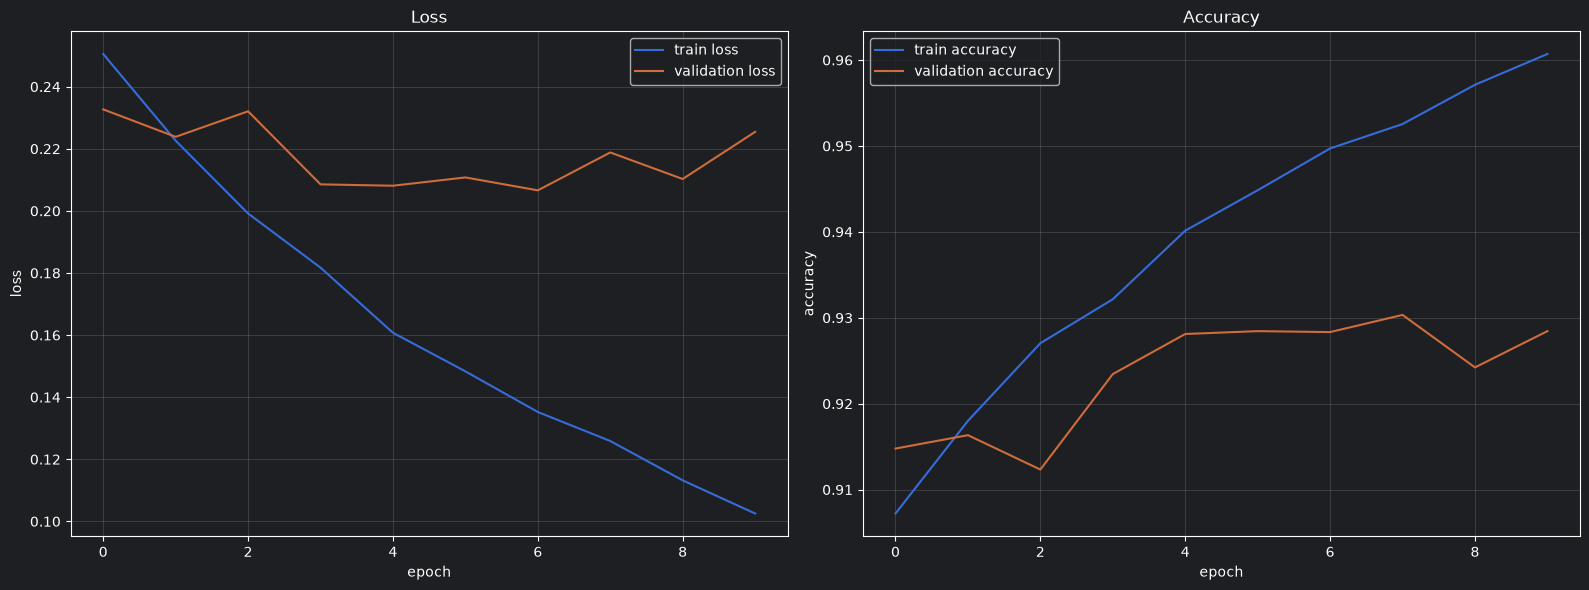

In [17]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train accuracy")
plt.plot(history["val_acc"], label="validation accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5. 모델 평가

### Test 데이터 성능 측정

test 데이터는 모델 학습과 조정에 사용하지 않고 마지막에 한 번 성능을 확인한다. `eval()`과 `no_grad()`를 사용해 Dropout과 기울기 계산을 끈다.

## 6. 특성맵 시각화

### 특성맵에 사용할 입력 이미지 확인

Feature map은 합성곱 필터가 입력의 어느 부분에 강하게 반응했는지 보여준다. 먼저 모델에 넣을 이미지 한 장과 입력 shape를 확인한다.

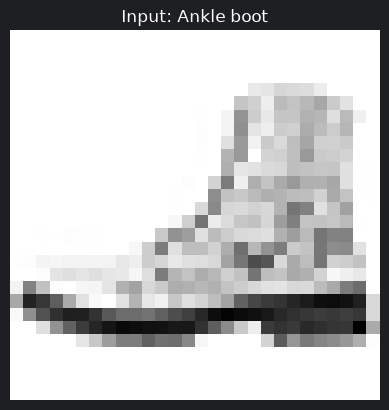

모델 입력 shape: torch.Size([1, 1, 28, 28])


In [21]:
sample_index = 1
sample_input = tr_images[sample_index:sample_index + 1].to(device)

sample_display = tr_images[sample_index].squeeze(0) * 0.5 + 0.5
sample_label_index = tr_labels[sample_index].item()

plt.imshow(sample_display, cmap="gray_r")
plt.title(f"Input: {class_names[sample_label_index]}")
plt.axis("off")
plt.show()

print("모델 입력 shape:", sample_input.shape)


### Forward hook으로 중간 출력 저장

`register_forward_hook`은 모델의 순전파가 실행될 때 특정 계층의 출력을 저장한다. 모델 코드를 바꾸지 않고 `conv1`, `conv2`의 feature map을 관찰할 수 있다.

In [22]:
class FeatureExtractor:
    def __init__(self, model, layer_name):
        self.model = model
        self.features = None

        layer = dict(model.named_modules())[layer_name]

        self.handle = layer.register_forward_hook(self._save_output)

    def _save_output(self, module, module_inputs, module_output):

        self.features = module_output.detach()

    def get_features(self, inputs):

        self.model.eval()
        with torch.no_grad():
            _ = self.model(inputs)
        return self.features

    def close(self):

        self.handle.remove()


### 첫 번째 합성곱 계층의 feature map

`conv1`은 입력 흑백 이미지에서 서로 다른 32가지 패턴을 찾는다. 각 채널은 하나의 필터가 만든 반응 결과이다.

conv1 feature map shape: torch.Size([1, 32, 28, 28])


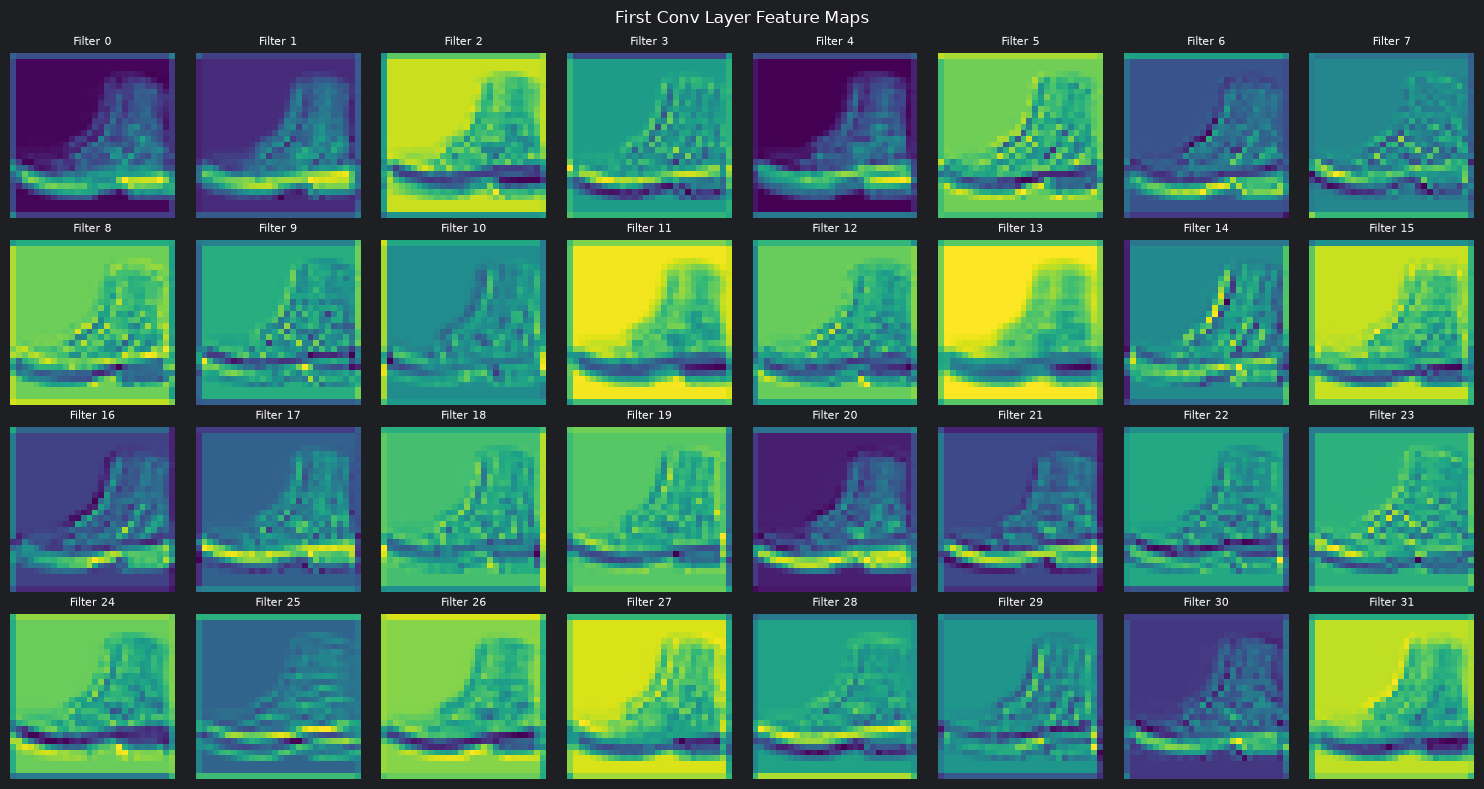

In [23]:
conv1_extractor = FeatureExtractor(model, "conv1")
conv1_feature_maps = conv1_extractor.get_features(sample_input)
conv1_extractor.close()

print("conv1 feature map shape:", conv1_feature_maps.shape)

conv1_maps = conv1_feature_maps.cpu().numpy()

figure, axes = plt.subplots(4, 8, figsize=(15, 8))
for row in range(4):
    for column in range(8):
        channel = row * 8 + column

        axes[row, column].imshow(conv1_maps[0, channel], cmap="viridis")
        axes[row, column].set_title(f"Filter {channel}", fontsize=8)
        axes[row, column].axis("off")

plt.suptitle("First Conv Layer Feature Maps")
plt.tight_layout()
plt.show()


### 두 번째 합성곱 계층의 feature map

`conv2`는 `conv1`이 찾은 단순한 특징들을 조합해 64개 feature map을 만든다. padding이 없기 때문에 공간 크기는 28×28에서 26×26으로 줄어든다.

conv2 feature map shape: torch.Size([1, 64, 26, 26])


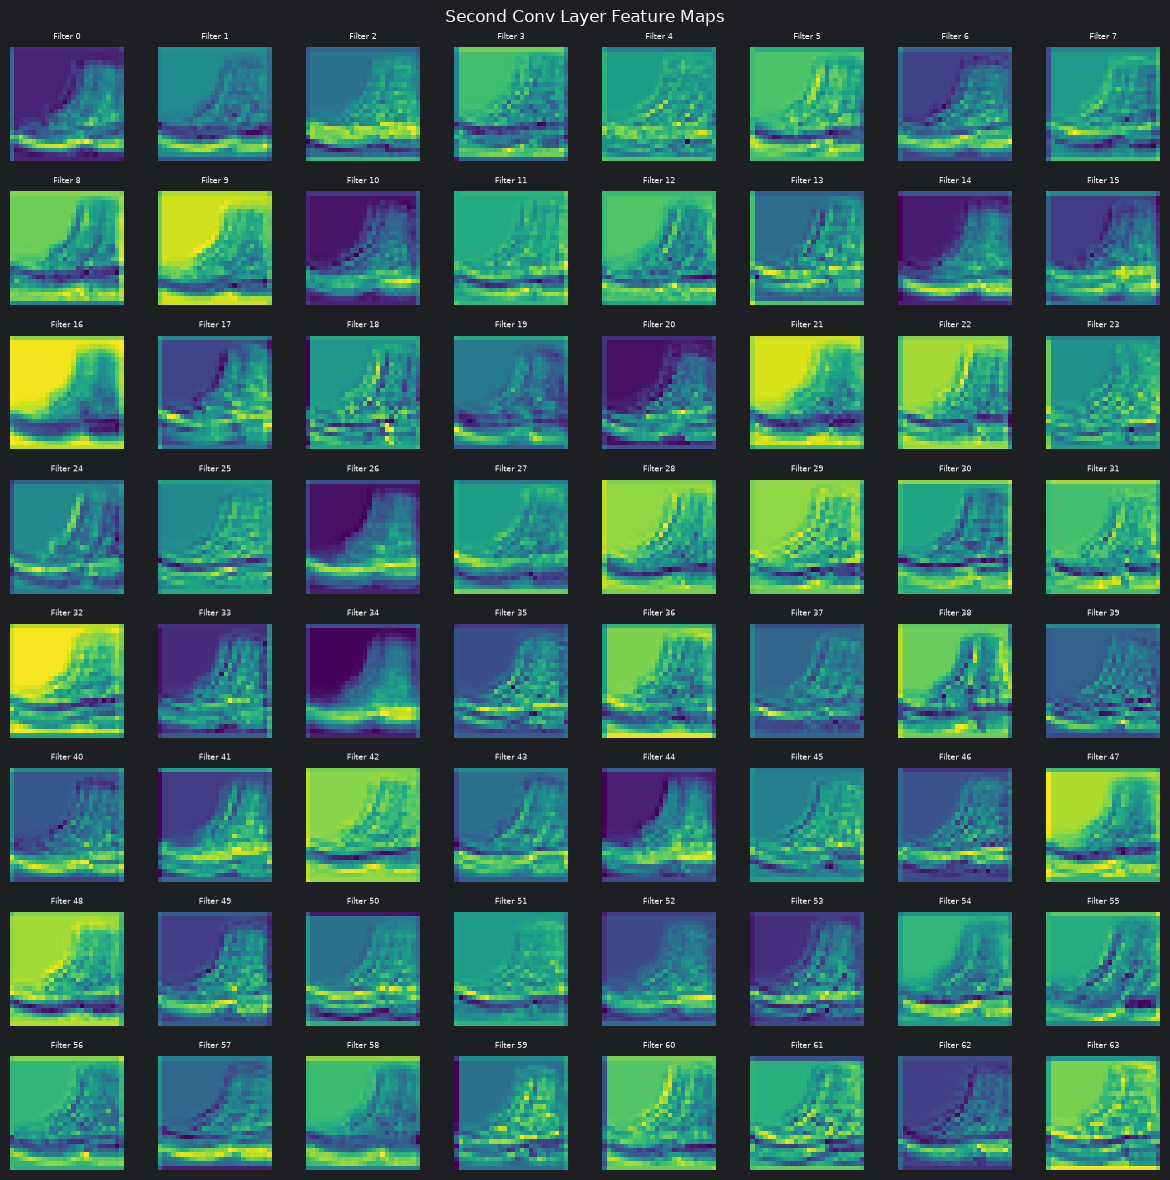

In [24]:
conv2_extractor = FeatureExtractor(model, "conv2")
conv2_feature_maps = conv2_extractor.get_features(sample_input)
conv2_extractor.close()

print("conv2 feature map shape:", conv2_feature_maps.shape)

conv2_maps = conv2_feature_maps.cpu().numpy()

figure, axes = plt.subplots(8, 8, figsize=(12, 12))
for row in range(8):
    for column in range(8):
        channel = row * 8 + column
        axes[row, column].imshow(conv2_maps[0, channel], cmap="viridis")
        axes[row, column].set_title(f"Filter {channel}", fontsize=6)
        axes[row, column].axis("off")

plt.suptitle("Second Conv Layer Feature Maps")
plt.tight_layout()
plt.show()


## 핵심 정리

- 흑백 이미지 한 장은 `(C=1, H=28, W=28)`, mini-batch는 `(N, 1, 28, 28)` 형태이다.
- CNN은 합성곱으로 특징을 찾고 pooling으로 공간 크기를 줄인 뒤 Linear 계층으로 분류한다.
- 마지막 계층은 Softmax를 적용하지 않은 logits 10개를 출력하며 `CrossEntropyLoss`가 이를 정답과 비교한다.
- 학습에서는 `train()`, 역전파, optimizer 갱신을 사용하고 평가에서는 `eval()`과 `no_grad()`를 사용한다.
- feature map을 보면 각 합성곱 필터가 입력 이미지의 서로 다른 특징에 반응한다는 것을 확인할 수 있다.

In [25]:
from pathlib import Path

import numpy as np
from PIL import Image, ImageOps
from torchvision.transforms import functional as TF


def preprocess_external_image(image_path):
    # convert("L")은 RGB 사진을 밝기값 하나를 갖는 흑백 1채널 이미지로 바꾼다.
    grayscale_image = Image.open(image_path).convert("L")

    # autocontrast는 가장 어두운 값과 밝은 값의 차이를 넓혀 의류 윤곽을 더 분명하게 만든다.
    grayscale_image = ImageOps.autocontrast(grayscale_image)

    # 이미지 가장자리 평균으로 배경 밝기를 추정한다.
    # FashionMNIST는 검은 배경에 밝은 의류이므로 가장자리가 밝으면 명암을 반전한다.
    pixel_array = np.asarray(grayscale_image, dtype=np.float32) / 255.0
    border_pixels = np.concatenate([
        pixel_array[0, :],
        pixel_array[-1, :],
        pixel_array[:, 0],
        pixel_array[:, -1],
    ])
    if border_pixels.mean() > 0.5:
        grayscale_image = ImageOps.invert(grayscale_image)

    # ImageOps.pad는 원본 비율을 유지한 채 28×28 안에 맞추고 남는 영역을 검은색으로 채운다.
    resized_image = ImageOps.pad(
        grayscale_image,
        size=(28, 28),
        method=Image.Resampling.LANCZOS,
        color=0,
    )

    # to_tensor는 (H, W) 이미지를 (C=1, H=28, W=28) float32 Tensor로 바꾸고 0~1로 스케일링한다.
    image_tensor = TF.to_tensor(resized_image)
    display_image = image_tensor.squeeze(0)

    # 모델이 학습한 입력과 동일하게 0~1을 -1~1 범위로 바꾼다.
    normalized_tensor = (image_tensor - 0.5) / 0.5

    # 모델은 (N, C, H, W)를 받으므로 맨 앞에 N=1인 batch 축을 추가한다.
    model_input = normalized_tensor.unsqueeze(0)
    return model_input, display_image

선택한 파일: coat1.jpg
최종 예측: Dress
예측 확률: 11.5%
상위 3개 예측: Dress 11.5%, Shirt 10.7%, Coat 10.0%


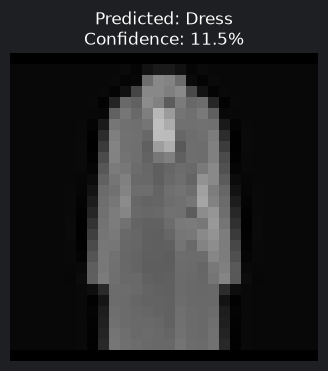

In [26]:
# 실제 사진을 저장할 폴더와 읽을 수 있는 이미지 확장자를 지정한다.
external_image_dir = Path.cwd() / "data" / "external_fashion"
supported_extensions = {".jpg", ".jpeg", ".png", ".webp"}

# 파일명은 자유롭게 사용할 수 있으며 여러 장이면 이름순 첫 번째 파일만 선택한다.
external_image_paths = (
    sorted(
        path
        for path in external_image_dir.iterdir()
        if path.is_file() and path.suffix.lower() in supported_extensions
    )
    if external_image_dir.exists()
    else []
)

if not external_image_paths:
    # 선택 실습용 사진이 없으면 모델을 호출하지 않고 필요한 폴더만 안내한다.
    print("분류할 사진이 없습니다. 다음 폴더에 이미지 한 장을 넣으세요.")
    print(external_image_dir)
else:
    image_path = external_image_paths[0]

    # 앞에서 정의한 함수로 실제 사진을 모델 입력과 시각화용 이미지로 변환한다.
    model_input, display_image = preprocess_external_image(image_path)

    # 평가 모드에서는 Dropout을 끄고, no_grad는 추론에 불필요한 기울기 계산을 생략한다.
    model.eval()
    with torch.no_grad():
        logits = model(model_input.to(device))

        # Softmax는 logits 10개를 합이 1인 클래스별 확률로 바꾼다.
        probabilities = torch.softmax(logits, dim=1)[0]
        top_probabilities, top_indices = probabilities.topk(k=3)

    predicted_index = top_indices[0].item()
    predicted_probability = top_probabilities[0].item()

    # 상위 3개 클래스 번호를 이름과 확률로 바꾸어 한 줄로 표시한다.
    top3_text = ", ".join(
        f"{class_names[index]} {probability:.1%}"
        for probability, index in zip(
            top_probabilities.cpu().tolist(),
            top_indices.cpu().tolist(),
        )
    )

    print("선택한 파일:", image_path.name)
    print("최종 예측:", class_names[predicted_index])
    print("예측 확률:", f"{predicted_probability:.1%}")
    print("상위 3개 예측:", top3_text)

    # Matplotlib 기본 글꼴의 한글 경고를 피하기 위해 그래프 제목은 영문으로 작성한다.
    plt.figure(figsize=(4, 4))
    plt.imshow(display_image, cmap="gray", vmin=0, vmax=1)
    plt.title(
        f"Predicted: {class_names[predicted_index]}\n"
        f"Confidence: {predicted_probability:.1%}"
    )
    plt.axis("off")
    plt.show()

### 학습 모델 저장

In [28]:
import joblib
import copy
from pathlib import Path

MODEL_DIR = Path("./models")
MODEL_DIR.mkdir(exist_ok=True, parents=True)

model_path = MODEL_DIR / "fashion_mnist_cnn.joblib"

# copy를 통해서 원본 모델은 유지
# 어떤 환경에서도 사용할 수 있도록 device를 cpu로 변경
model_to_save = copy.deepcopy(model).to("cpu")
model_to_save.eval()

# 저장
joblib.dump(model_to_save, model_path)
print("저장 완료 - ", model_path)

저장 완료 -  models\fashion_mnist_cnn.joblib


### 저장한 모델 불러오기
- 불러오기 전에 모델 클래스부터 실행

In [5]:
import joblib

model = joblib.load("./models/fashion_mnist_cnn.joblib")

# device 변경
# model = model.to("cuda" if torch.cuda.is_available() else "cpu")

model.eval() # 평가모드 -> 잘못된 학습 방지

FashionMNISTCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=10816, out_features=100, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=100, out_features=10, bias=True)
)